# Raw line family only experiment

Ten notebook jest calkowicie odseparowany od poprzednich eksperymentow.

Obecna wersja robi:
- wczytanie obrazu,
- grayscale,
- odszumienie,
- binaryzacje,
- cleanup,
- przypisanie surowych segmentow do rodzin `horizontal` i `vertical`,
- budowe wstepnych `LogicalLine`,
- render `raw line families` na `cleanup`,
- repair,
- pixel-validated laczenie koncow linii na `repair`,
- budowe prostokatow tolerancji,
- render logical lines i prostokatow tolerancji.

Ta wersja nadal nie liczy:
- warp,
- finalnej siatki planszy,
- komorek,
- OCR cyfr.

In [1]:
import bootstrap as bootstrap
from pipeline import (
    RawLineFamilyArtifacts,
    build_raw_line_family_plot_items,
    configure_manual_image_path,
    describe_raw_line_family_artifacts,
    resolve_active_image_selection,
)

In [2]:
import importlib
import pipeline as pipeline

bootstrap = importlib.reload(bootstrap)
pipeline = importlib.reload(pipeline)
API = bootstrap.load_api()

ExperimentConfig = API.ExperimentConfig
REPO_ROOT = API.REPO_ROOT
RawLineFamilyArtifacts = pipeline.RawLineFamilyArtifacts
build_raw_line_family_plot_items = pipeline.build_raw_line_family_plot_items
configure_manual_image_path = pipeline.configure_manual_image_path
describe_raw_line_family_artifacts = pipeline.describe_raw_line_family_artifacts
resolve_active_image_selection = pipeline.resolve_active_image_selection

print("Reloaded raw line family only API, pipeline, and local modules.")

Reloaded raw line family only API, pipeline, and local modules.


In [3]:
CONFIG = ExperimentConfig(
    raw_hough_threshold=35,
    raw_min_line_length_ratio=0.08,
    raw_max_line_gap_ratio=0.005,
)

print(f"Repo root: {REPO_ROOT}")
print(f"Dataset root: {CONFIG.dataset_root}")
print(
    "Pipeline: "
    f"median_{CONFIG.median_kernel_size} -> "
    "gaussian_block"
    f"{CONFIG.adaptive_threshold_block_size}_c"
    f"{CONFIG.adaptive_threshold_c_value} -> "
    "adaptive_plus_components_soft -> directional_close"
)
print(
    "Tolerance rectangles: "
    f"length={CONFIG.tolerance_rectangle_vector_length_px}, "
    f"padding={CONFIG.tolerance_rectangle_padding_px}"
)

Repo root: /home/wojtek/projects/sudoku
Dataset root: /home/wojtek/projects/sudoku/data/raw/boards
Pipeline: median_5 -> gaussian_block11_c2 -> adaptive_plus_components_soft -> directional_close
Tolerance rectangles: length=350, padding=18


## 1. Wybor obrazka

Mozesz wpisac reczna sciezke albo zostawic puste `IMAGE_PATH_INPUT` i wybrac obraz przez `CONFIG.selected_dataset_index`.

In [4]:
IMAGE_PATH_INPUT = "/home/wojtek/projects/sudoku/examples/uploads/image1087.jpg"
# Przyklad:
# IMAGE_PATH_INPUT = "data/raw/boards/przyklad/board_01.jpg"
# IMAGE_PATH_INPUT = ""
3
print(configure_manual_image_path(CONFIG, IMAGE_PATH_INPUT, REPO_ROOT))

Manual image path enabled: /home/wojtek/projects/sudoku/examples/uploads/image1087.jpg


In [5]:
IMAGE_SELECTION = resolve_active_image_selection(CONFIG, API)
ACTIVE_IMAGE_PATH = IMAGE_SELECTION.active_image_path

for line in IMAGE_SELECTION.preview_lines:
    print(line)

Found 250 image(s) under dataset root.
[00] mixed/image1.jpg
[01] mixed/image10.jpg
[02] mixed/image100.jpg
[03] mixed/image102.jpg
[04] mixed/image103.jpg
[05] mixed/image104.jpg
[06] mixed/image106.jpg
[07] mixed/image107.jpg
[08] mixed/image109.jpg
[09] mixed/image111.jpg
[10] mixed/image112.jpg
[11] mixed/image113.jpg
[12] mixed/image114.jpg
[13] mixed/image117.jpg
[14] mixed/image118.jpg
[15] mixed/image119.jpg
[16] mixed/image120.jpg
[17] mixed/image122.jpg
[18] mixed/image125.jpg
[19] mixed/image126.jpg
... and 230 more

Active image: /home/wojtek/projects/sudoku/examples/uploads/image1087.jpg


In [6]:
import cv2

SOURCE_BGR = API.load_image_bgr(ACTIVE_IMAGE_PATH)
DISPLAY_BGR = API.resize_for_display(SOURCE_BGR, CONFIG.max_display_size)
GRAY_IMAGE = cv2.cvtColor(DISPLAY_BGR, cv2.COLOR_BGR2GRAY)

DENOISE_NAME = f"median_{CONFIG.median_kernel_size}"
DENOISED_IMAGE = API.apply_median_denoise(
    GRAY_IMAGE,
    CONFIG,
)

THRESHOLD_NAME = (
    "gaussian_block"
    f"{CONFIG.adaptive_threshold_block_size}_c{CONFIG.adaptive_threshold_c_value}"
)
BINARY_IMAGE = API.apply_gaussian_threshold(
    DENOISED_IMAGE,
    CONFIG,
)

CLEANUP_NAME = "adaptive_plus_components_soft"
MIN_COMPONENT_AREA_PX, CLEAN_BINARY = API.apply_soft_component_cleanup(
    BINARY_IMAGE,
    CONFIG,
)

FAMILY_DETECTION_RESULT = API.detect_line_families(
    CLEAN_BINARY,
    CONFIG,
    include_logical_lines=False,
)
CLEANUP_BINARY_FAMILY_OVERLAY, SOURCE_FAMILY_OVERLAY = API.build_line_family_overlays(
    DISPLAY_BGR,
    CLEAN_BINARY,
    FAMILY_DETECTION_RESULT,
    CONFIG,
)


Repair time: 0.005s
Detect + logical lines + pixel connection time with Hough only on cleanup and pixels on repair: 3.897s
Pixel render binary: repair binary used for pixel connection

Original shape: (1280, 960, 3)
Display shape:  (1280, 960, 3)
Denoise: median_5
Threshold: gaussian_block11_c2
Cleanup: adaptive_plus_components_soft
Repair: directional_close
Connected components min area px: 74
Raw Hough segments: 212
Orientation offset degrees: -0.6408348353691053
Horizontal family segments: 96
Vertical family segments: 115
Horizontal final logical lines after intersections/frame: 2
Vertical final logical lines after intersections/frame: 2
Horizontal same-axis connection segments: 0
Vertical same-axis connection segments: 0
Horizontal cross-axis connection segments: 0
Vertical cross-axis connection segments: 0
Horizontal tolerance rectangles: 4
Vertical tolerance rectangles: 4
Logical line intersections: 4
Logical line crosses / touches: 0 / 0
Mutual boundary intersections / border pa

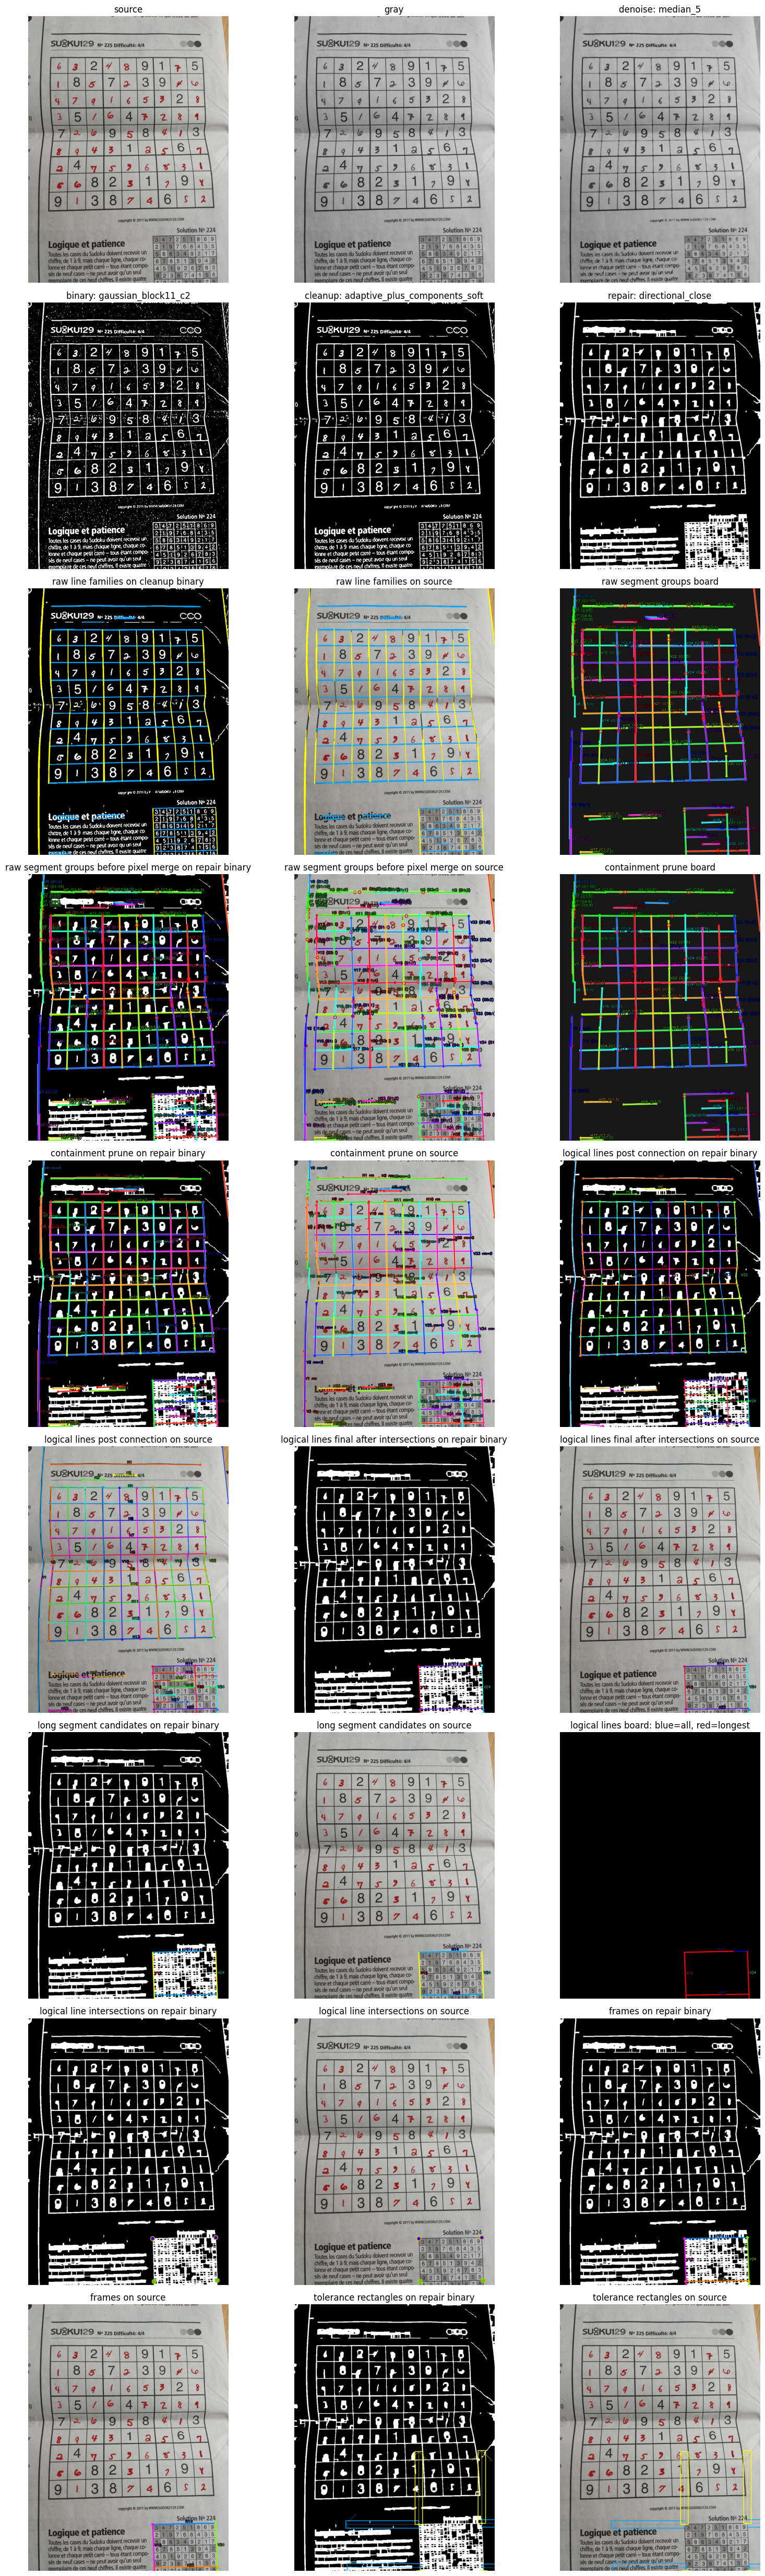

In [7]:
import time

REPAIR_NAME = "directional_close"
repair_started_at = time.perf_counter()
REPAIRED_BINARY = API.apply_directional_close_repair(
    CLEAN_BINARY,
    CONFIG,
)
repair_elapsed_s = time.perf_counter() - repair_started_at

PIXEL_CONNECTION_BINARY_NAME = "repair"
# Do testu mozna przelaczyc na:
# PIXEL_CONNECTION_BINARY_NAME = "cleanup"

if PIXEL_CONNECTION_BINARY_NAME == "cleanup":
    PIXEL_CONNECTION_BINARY = CLEAN_BINARY
elif PIXEL_CONNECTION_BINARY_NAME == "repair":
    PIXEL_CONNECTION_BINARY = REPAIRED_BINARY
else:
    raise ValueError(
        "PIXEL_CONNECTION_BINARY_NAME must be 'cleanup' or 'repair'."
    )

full_detection_started_at = time.perf_counter()
FINAL_LINE_FAMILY_RESULT = API.detect_line_families(
    CLEAN_BINARY,
    CONFIG,
    pixel_connection_binary_image=PIXEL_CONNECTION_BINARY,
)
full_detection_elapsed_s = time.perf_counter() - full_detection_started_at

PIXEL_RENDER_BINARY_NAME = (
    f"{PIXEL_CONNECTION_BINARY_NAME} binary used for pixel connection"
)
(
    BINARY_RAW_SEGMENT_GROUP_OVERLAY,
    SOURCE_RAW_SEGMENT_GROUP_OVERLAY,
) = API.build_raw_segment_group_overlays(
    DISPLAY_BGR,
    PIXEL_CONNECTION_BINARY,
    FINAL_LINE_FAMILY_RESULT,
    CONFIG,
)
RAW_SEGMENT_GROUP_BOARD = API.build_raw_segment_group_board(
    DISPLAY_BGR,
    FINAL_LINE_FAMILY_RESULT,
    CONFIG,
)
(
    BINARY_CONTAINMENT_PRUNE_OVERLAY,
    SOURCE_CONTAINMENT_PRUNE_OVERLAY,
) = API.build_containment_prune_overlays(
    DISPLAY_BGR,
    PIXEL_CONNECTION_BINARY,
    FINAL_LINE_FAMILY_RESULT,
    CONFIG,
)
CONTAINMENT_PRUNE_BOARD = API.build_containment_prune_board(
    DISPLAY_BGR,
    FINAL_LINE_FAMILY_RESULT,
    CONFIG,
)
(
    BINARY_VERTEX_CONTAINMENT_MERGE_OVERLAY,
    SOURCE_VERTEX_CONTAINMENT_MERGE_OVERLAY,
) = API.build_vertex_containment_merge_overlays(
    DISPLAY_BGR,
    PIXEL_CONNECTION_BINARY,
    FINAL_LINE_FAMILY_RESULT,
    CONFIG,
)
VERTEX_CONTAINMENT_MERGE_BOARD = API.build_vertex_containment_merge_board(
    DISPLAY_BGR,
    FINAL_LINE_FAMILY_RESULT,
    CONFIG,
)
(
    BINARY_POST_MERGE_LOGICAL_LINE_OVERLAY,
    SOURCE_POST_MERGE_LOGICAL_LINE_OVERLAY,
) = API.build_post_merge_logical_line_overlays(
    DISPLAY_BGR,
    PIXEL_CONNECTION_BINARY,
    FINAL_LINE_FAMILY_RESULT,
    CONFIG,
)
(
    BINARY_POST_CONNECTION_LOGICAL_LINE_OVERLAY,
    SOURCE_POST_CONNECTION_LOGICAL_LINE_OVERLAY,
) = API.build_post_connection_logical_line_overlays(
    DISPLAY_BGR,
    PIXEL_CONNECTION_BINARY,
    FINAL_LINE_FAMILY_RESULT,
    CONFIG,
)
BINARY_LOGICAL_LINE_OVERLAY, SOURCE_LOGICAL_LINE_OVERLAY = API.build_logical_line_overlays(
    DISPLAY_BGR,
    PIXEL_CONNECTION_BINARY,
    FINAL_LINE_FAMILY_RESULT,
    CONFIG,
)
(
    BINARY_LONG_SEGMENT_CANDIDATE_OVERLAY,
    SOURCE_LONG_SEGMENT_CANDIDATE_OVERLAY,
) = API.build_long_segment_candidate_overlays(
    DISPLAY_BGR,
    PIXEL_CONNECTION_BINARY,
    FINAL_LINE_FAMILY_RESULT,
    CONFIG,
)
LONG_SEGMENT_CANDIDATE_BOARD = API.build_long_segment_candidate_board(
    DISPLAY_BGR,
    FINAL_LINE_FAMILY_RESULT,
    CONFIG,
)
(
    BINARY_LOGICAL_LINE_INTERSECTION_OVERLAY,
    SOURCE_LOGICAL_LINE_INTERSECTION_OVERLAY,
) = API.build_logical_line_intersection_overlays(
    DISPLAY_BGR,
    PIXEL_CONNECTION_BINARY,
    FINAL_LINE_FAMILY_RESULT,
    CONFIG,
)
(
    BINARY_FRAME_OVERLAY,
    SOURCE_FRAME_OVERLAY,
) = API.build_frame_overlays(
    DISPLAY_BGR,
    PIXEL_CONNECTION_BINARY,
    FINAL_LINE_FAMILY_RESULT,
    CONFIG,
)
(
    BINARY_TOLERANCE_RECTANGLE_OVERLAY,
    SOURCE_TOLERANCE_RECTANGLE_OVERLAY,
) = API.build_tolerance_rectangle_overlays(
    DISPLAY_BGR,
    PIXEL_CONNECTION_BINARY,
    FINAL_LINE_FAMILY_RESULT,
    CONFIG,
)

ARTIFACTS = RawLineFamilyArtifacts(
    source_bgr=SOURCE_BGR,
    display_bgr=DISPLAY_BGR,
    gray_image=GRAY_IMAGE,
    denoise_name=DENOISE_NAME,
    denoised_image=DENOISED_IMAGE,
    threshold_name=THRESHOLD_NAME,
    binary_image=BINARY_IMAGE,
    min_component_area_px=MIN_COMPONENT_AREA_PX,
    cleanup_name=CLEANUP_NAME,
    clean_binary=CLEAN_BINARY,
    repair_name=REPAIR_NAME,
    repaired_binary=REPAIRED_BINARY,
    line_family_result=FINAL_LINE_FAMILY_RESULT,
    binary_family_overlay=CLEANUP_BINARY_FAMILY_OVERLAY,
    source_family_overlay=SOURCE_FAMILY_OVERLAY,
    raw_segment_group_board=RAW_SEGMENT_GROUP_BOARD,
    binary_raw_segment_group_overlay=BINARY_RAW_SEGMENT_GROUP_OVERLAY,
    source_raw_segment_group_overlay=SOURCE_RAW_SEGMENT_GROUP_OVERLAY,
    containment_prune_board=CONTAINMENT_PRUNE_BOARD,
    binary_containment_prune_overlay=BINARY_CONTAINMENT_PRUNE_OVERLAY,
    source_containment_prune_overlay=SOURCE_CONTAINMENT_PRUNE_OVERLAY,
    vertex_containment_merge_board=VERTEX_CONTAINMENT_MERGE_BOARD,
    binary_vertex_containment_merge_overlay=(
        BINARY_VERTEX_CONTAINMENT_MERGE_OVERLAY
    ),
    source_vertex_containment_merge_overlay=(
        SOURCE_VERTEX_CONTAINMENT_MERGE_OVERLAY
    ),
    binary_post_merge_logical_line_overlay=(
        BINARY_POST_MERGE_LOGICAL_LINE_OVERLAY
    ),
    source_post_merge_logical_line_overlay=(
        SOURCE_POST_MERGE_LOGICAL_LINE_OVERLAY
    ),
    binary_post_connection_logical_line_overlay=(
        BINARY_POST_CONNECTION_LOGICAL_LINE_OVERLAY
    ),
    source_post_connection_logical_line_overlay=(
        SOURCE_POST_CONNECTION_LOGICAL_LINE_OVERLAY
    ),
    binary_logical_line_overlay=BINARY_LOGICAL_LINE_OVERLAY,
    source_logical_line_overlay=SOURCE_LOGICAL_LINE_OVERLAY,
    binary_long_segment_candidate_overlay=BINARY_LONG_SEGMENT_CANDIDATE_OVERLAY,
    source_long_segment_candidate_overlay=SOURCE_LONG_SEGMENT_CANDIDATE_OVERLAY,
    long_segment_candidate_board=LONG_SEGMENT_CANDIDATE_BOARD,
    binary_logical_line_intersection_overlay=(
        BINARY_LOGICAL_LINE_INTERSECTION_OVERLAY
    ),
    source_logical_line_intersection_overlay=(
        SOURCE_LOGICAL_LINE_INTERSECTION_OVERLAY
    ),
    binary_frame_overlay=BINARY_FRAME_OVERLAY,
    source_frame_overlay=SOURCE_FRAME_OVERLAY,
    binary_tolerance_rectangle_overlay=BINARY_TOLERANCE_RECTANGLE_OVERLAY,
    source_tolerance_rectangle_overlay=SOURCE_TOLERANCE_RECTANGLE_OVERLAY,
)

print(f"Repair time: {repair_elapsed_s:.3f}s")
print(
    "Detect + logical lines + pixel connection time "
    f"with Hough only on cleanup and pixels on {PIXEL_CONNECTION_BINARY_NAME}: "
    f"{full_detection_elapsed_s:.3f}s"
)
print(f"Pixel render binary: {PIXEL_RENDER_BINARY_NAME}")
print()

for line in describe_raw_line_family_artifacts(ARTIFACTS):
    print(line)

API.plot_named_images(
    build_raw_line_family_plot_items(ARTIFACTS),
    columns=3,
    figure_scale=5.5,
)